In [15]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_parquet("master_monthly.parquet")

# Sort by date
df = df.sort_values("month").set_index("month")

# Keep only rows where india_price exists
df = df.dropna(subset=["india_price"])

In [16]:
# -----------------------------
# LAGS (memory of past prices)
# -----------------------------
for l in [2, 4, 5, 9, 18, 24]:
    df[f"lag_{l}"] = df["india_price"].shift(l)

# -----------------------------
# ROLLING MEANS (trend)
# -----------------------------
df["roll3"] = df["india_price"].rolling(3).mean()
df["roll6"] = df["india_price"].rolling(6).mean()
df["roll12"] = df["india_price"].rolling(12).mean()

# -----------------------------
# VOLATILITY (risk)
# -----------------------------
df["vol3"] = df["india_price"].pct_change().rolling(3).std()
df["vol6"] = df["india_price"].pct_change().rolling(6).std()

# -----------------------------
# MOMENTUM (direction)
# -----------------------------
df["mom1"] = df["india_price"].diff(1)
df["mom3"] = df["india_price"].diff(3)
df["mom6"] = df["india_price"].diff(6)

# -----------------------------
# ROLLING MIN/MAX (local range)
# -----------------------------
df["roll_min_6"] = df["india_price"].rolling(6).min()
df["roll_max_6"] = df["india_price"].rolling(6).max()

# -----------------------------
# SEASONALITY (month dummies)
# -----------------------------
df["month_num"] = df.index.month
df = pd.get_dummies(df, columns=["month_num"], drop_first=True)

In [17]:
# -----------------------------
# CREATE RETURN-BASED TARGET
# -----------------------------
df["return"] = df["india_price"].pct_change()

# Drop the first row (because pct_change creates NaN)
df = df.dropna(subset=["return"])

In [18]:
df[["oil_price", "usd_inr", "fao_cereals", "fertiliser_index", "gepu"]] = \
df[["oil_price", "usd_inr", "fao_cereals", "fertiliser_index", "gepu"]].ffill()

In [19]:
df["conflict_events"] = df["conflict_events"].fillna(0)

In [20]:
df["rainfall"] = df["rainfall"].fillna(df["rainfall"].mean())

In [21]:
df["temperature"] = df["temperature"].fillna(df["temperature"].mean())

In [22]:
df.head()

,india_price,global_wheat_price,fao_cereals,oil_price,usd_inr,conflict_events,rainfall,fertiliser_index,gepu,temperature,...,month_num_4,month_num_5,month_num_6,month_num_7,month_num_8,month_num_9,month_num_10,month_num_11,month_num_12,return
month,,,,,,,,,,,,,,,,,,,,,
2001-03-01,659.63,NaN,52.2,27.244545,46.653182,0.0,4.110216,NaN,112.151962,24.397714,...,False,False,False,False,False,False,False,False,False,-0.144449
2001-04-01,899.84,NaN,51.0,27.490000,46.788571,0.0,4.110216,NaN,107.023471,27.390286,...,True,False,False,False,False,False,False,False,False,0.364159
2001-05-01,854.90,NaN,51.7,28.629091,46.947273,0.0,4.110216,NaN,82.950790,29.495143,...,False,True,False,False,False,False,False,False,False,-0.049942
2001-06-01,855.46,NaN,51.0,27.599048,47.042381,0.0,4.110216,NaN,74.085198,27.842857,...,False,False,True,False,False,False,False,False,False,0.000655
2001-07-01,830.96,NaN,51.7,26.424762,47.178095,0.0,4.110216,NaN,97.386014,26.959143,...,False,False,False,True,False,False,False,False,False,-0.028640


In [23]:
df.isna().sum().sort_values(ascending=False)

global_wheat_price    63
fertiliser_index      33
lag_24                23
lag_18                17
roll12                10
lag_9                  8
mom6                   5
vol6                   5
roll_min_6             4
lag_5                  4
roll6                  4
roll_max_6             4
lag_4                  3
mom3                   2
vol3                   2
roll3                  1
lag_2                  1
conflict_events        0
india_price            0
usd_inr                0
oil_price              0
fao_cereals            0
mom1                   0
temperature            0
rainfall               0
gepu                   0
month_num_2            0
month_num_3            0
month_num_4            0
month_num_5            0
month_num_6            0
month_num_7            0
month_num_8            0
month_num_9            0
month_num_10           0
month_num_11           0
month_num_12           0
return                 0
dtype: int64

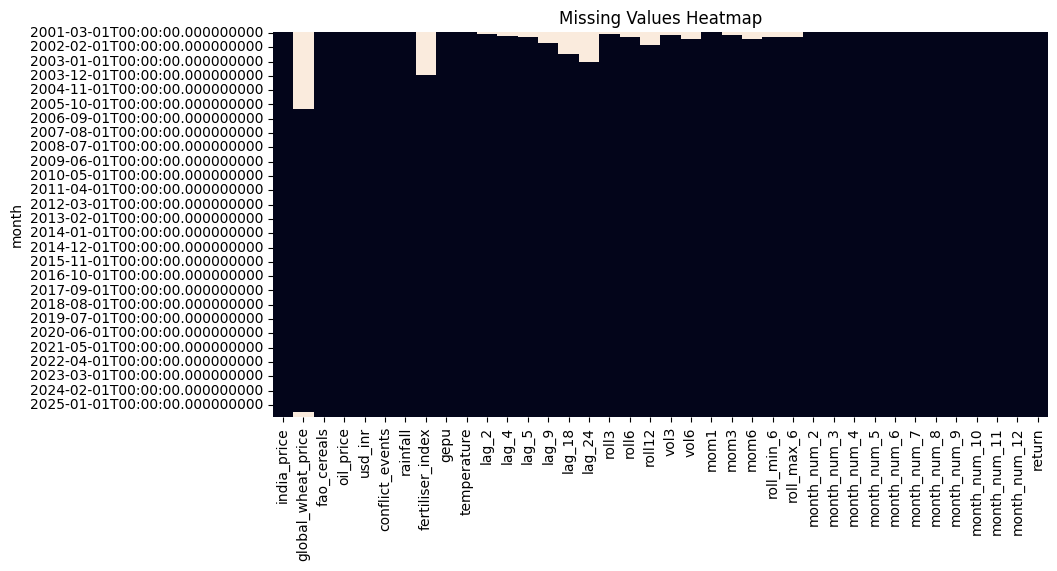

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")

plt.savefig("missing_values_heatmap_before.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
df = df.dropna()

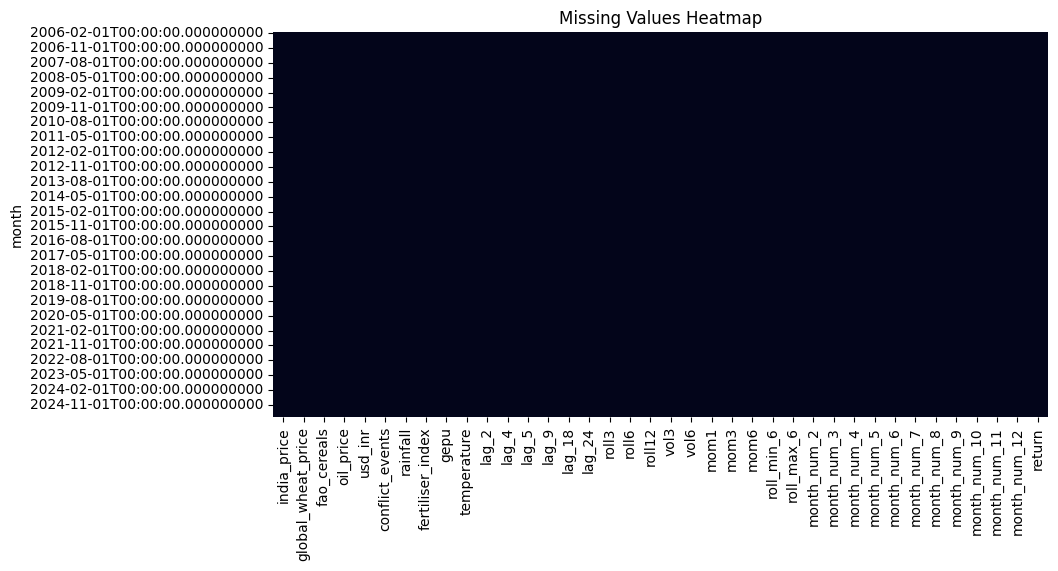

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# SCALERS
# -----------------------------
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# -----------------------------
# SCALE FEATURES (X)
# -----------------------------
feature_cols = df.drop(columns=["india_price", "return"]).columns
df_scaled_features = feature_scaler.fit_transform(df[feature_cols])

# -----------------------------
# SCALE TARGET (y = returns)
# -----------------------------
df_scaled_target = target_scaler.fit_transform(df[["return"]])

In [13]:
import numpy as np

# -----------------------------
# WINDOW SIZE (24 months)
# -----------------------------
window = 24

X = []
y = []

# Loop through the dataset and create sequences
for i in range(window, len(df)):
    X.append(df_scaled_features[i-window:i])   # past 24 months of features
    y.append(df_scaled_target[i])              # next month's return

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (209, 24, 36)
y shape: (209, 1)


In [14]:
# -----------------------------
# TRAIN/TEST SPLIT (70/30)
# -----------------------------
split = int(len(X) * 0.7)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (146, 24, 36) (146, 1)
Test shapes: (63, 24, 36) (63, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

def build_cnn_lstm_model():
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(24, 36)),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [16]:
cnn_lstm_model = build_cnn_lstm_model()

history = cnn_lstm_model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0517 - val_loss: 0.0305
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0337 - val_loss: 0.0361
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0263 - val_loss: 0.0128
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0254 - val_loss: 0.0210
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0217 - val_loss: 0.0109
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0205 - val_loss: 0.0194
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0237 - val_loss: 0.0119
Epoch 8/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0190 - val_loss: 0.0142
Epoch 9/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0217 - val_loss: 0.0231
Epoch 10/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0242 - val_loss: 0.0118
Epoch 11/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0149 - val_loss: 0.0155
Epoch 12/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0176 - val_loss: 0.0094
E

In [17]:
# -----------------------------
# PREDICT SCALED RETURNS
# -----------------------------
scaled_preds = cnn_lstm_model.predict(X_test)
# -----------------------------
# INVERSE TRANSFORM RETURNS
# -----------------------------
pred_returns = target_scaler.inverse_transform(scaled_preds)
true_returns = target_scaler.inverse_transform(y_test)
# -----------------------------
# RECONSTRUCT PRICES
# -----------------------------

# Get the actual price at the split point
start_price = df["india_price"].iloc[len(X_train) + 24 - 1]

# Convert returns → prices
pred_prices = [start_price]

for r in pred_returns:
    next_price = pred_prices[-1] * (1 + r[0])
    pred_prices.append(next_price)

# Remove the first element (start_price)
pred_prices = pred_prices[1:]

# Actual prices for the test period
actual_prices = df["india_price"].iloc[len(X_train) + 24:]
actual_prices = actual_prices[:len(pred_prices)]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


RMSE: 602.0513677171564
MAE: 487.96521767745423
R2: -2.048924133493726


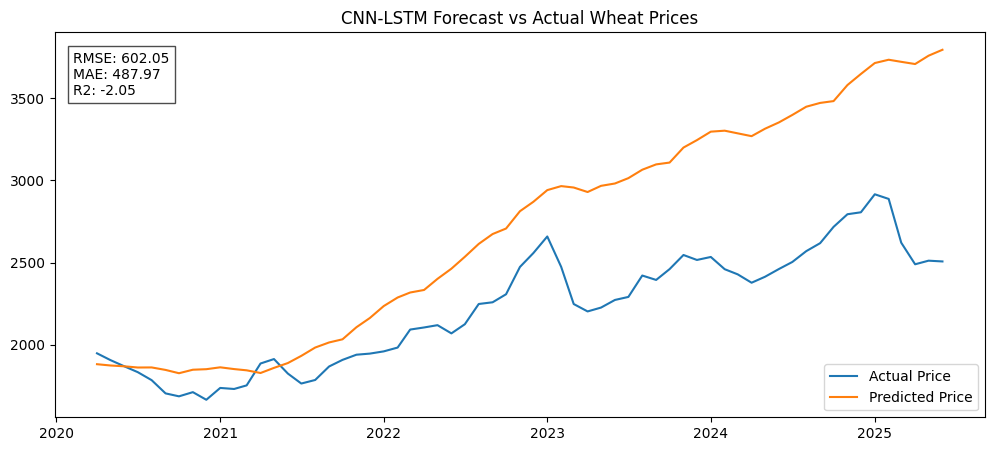

Saved to: CNN_plots\cnn_lstm_forecast_20260310_204641.png


In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
mae = mean_absolute_error(actual_prices, pred_prices)
r2 = r2_score(actual_prices, pred_prices)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

import os
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Choose your folder
folder = "CNN_plots"

# 2. Create folder if it doesn't exist
os.makedirs(folder, exist_ok=True)

# 3. Create a unique filename using timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"cnn_lstm_forecast_{timestamp}.png"

# 4. Full path
filepath = os.path.join(folder, filename)

# 5. Plot
plt.figure(figsize=(12,5))

plt.plot(actual_prices.index, actual_prices, label="Actual Price")
plt.plot(actual_prices.index, pred_prices, label="Predicted Price")

plt.legend()
plt.title("CNN-LSTM Forecast vs Actual Wheat Prices")

# Add RMSE and MAE inside the plot
plt.text(
    0.02, 0.95,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR2: {r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7)
)

# Save before showing
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

print("Saved to:", filepath)



In [19]:
# cnnmodelname = f"cnn_lstm_model_{timestamp}.keras"
# cnn_lstm_model.save(cnnmodelname)
# cnnmodelname = f"cnn_lstm_model_{timestamp}.h5"
# cnn_lstm_model.save(cnnmodelname)
# # cnn_lstm_model.save("cnn_lstm_model.keras")
# # cnn_lstm_model.save("cnn_lstm_model.h5")